# Прогнозирование стоимости жилой недвижимости

## Цель проекта

Разработать ML-модель для прогнозирования ориентировочной рыночной стоимости жилого объекта по данным объявления. Модель должна ускорить первичную оценку новых предложений.

После получения прогноза сервис может использоваться для первичной оценки новых предложений. Если запрашиваемая цена нового объявления существенно ниже прогнозной рыночной стоимости, такой объект может быть передан риелтору на приоритетную экспертную проверку.

In [67]:
import pandas as pd
import numpy as np

RANDOM_STATE = 42

df = pd.read_csv('data.csv')

print('Размер:', df.shape)
display(df.head(3))

Размер: (377185, 18)


,status,private pool,propertyType,street,baths,homeFacts,fireplace,city,schools,sqft,zipcode,beds,state,stories,mls-id,PrivatePool,MlsId,target
0,Active,NaN,Single Family Home,240 Heather Ln,3.5,"{'atAGlanceFacts': [{'factValue': '2019', 'factLabel': 'Year built...",Gas Logs,Southern Pines,"[{'rating': ['4', '4', '7', 'NR', '4', '7', 'NR', 'NR'], 'data': {...",2900,28387,4,NC,NaN,NaN,NaN,611019,"$418,000"
1,for sale,NaN,single-family home,12911 E Heroy Ave,3 Baths,"{'atAGlanceFacts': [{'factValue': '2019', 'factLabel': 'Year built...",NaN,Spokane Valley,"[{'rating': ['4/10', 'None/10', '4/10'], 'data': {'Distance': ['1....","1,947 sqft",99216,3 Beds,WA,2.0,NaN,NaN,201916904,"$310,000"
2,for sale,NaN,single-family home,2005 Westridge Rd,2 Baths,"{'atAGlanceFacts': [{'factValue': '1961', 'factLabel': 'Year built...",yes,Los Angeles,"[{'rating': ['8/10', '4/10', '8/10'], 'data': {'Distance': ['1.19m...","3,000 sqft",90049,3 Beds,CA,1.0,NaN,yes,FR19221027,"$2,895,000"


In [3]:
audit = (
    pd.DataFrame({
        'dtype': df.dtypes.astype(str),
        'missing': df.isna().sum(),
        'missing_pct': (df.isna().mean() * 100).round(2),
        'unique': df.nunique(dropna=True)
    })
    .sort_values(['missing_pct', 'unique'], ascending=[False, False])
)

display(audit)

duplicates_count = df.duplicated().sum()

print(f'Полных дубликатов: {duplicates_count:,}')
print(f'Доля полных дубликатов: {duplicates_count / len(df):.3%}')

,dtype,missing,missing_pct,unique
private pool,object,373004,98.89,1
mls-id,object,352243,93.39,24907
PrivatePool,object,336874,89.31,2
fireplace,object,274071,72.66,1652
stories,object,150716,39.96,347
baths,object,106338,28.19,229
beds,object,91282,24.20,1184
MlsId,object,66880,17.73,232944
sqft,object,40577,10.76,25405
status,object,39918,10.58,159


Полных дубликатов: 50
Доля полных дубликатов: 0.013%


## Первичная оценка и удаление дубликатов

На этапе первичного аудита выявлены полные дубликаты строк. Они не несут
дополнительной информации для обучения, поэтому удаляются до формирования
целевой переменной и признаков.

Поле `target` содержит цену в текстовом формате. Перед преобразованием его
в число необходимо проверить примеры значений и отделить объявления о продаже
от объявлений об аренде.

In [68]:
# Удаление полных дубликатов.

rows_before_dedup = len(df)

df = df.drop_duplicates().copy()

rows_after_dedup = len(df)
duplicates_removed = rows_before_dedup - rows_after_dedup

print(f'Размер до удаления дубликатов: {rows_before_dedup:,}')
print(f'Удалено полных дубликатов: {duplicates_removed:,}')
print(f'Размер после удаления дубликатов: {df.shape[0]:,} строк, {df.shape[1]} столбцов')

Размер до удаления дубликатов: 377,185
Удалено полных дубликатов: 50
Размер после удаления дубликатов: 377,135 строк, 18 столбцов


In [69]:
# Предварительный анализ целевой переменной и признака статуса объявления.

target_text = (
    df['target']
    .fillna('')
    .astype(str)
    .str.strip()
    .str.lower()
)

status_text = (
    df['status']
    .fillna('')
    .astype(str)
    .str.strip()
    .str.lower()
)

target_missing_count = df['target'].isna().sum()
target_monthly_rent_count = target_text.str.contains(
    r'/mo\b',
    regex=True
).sum()

rent_status_count = status_text.str.contains(
    r'\brent\b',
    regex=True
).sum()

print(f'Пропусков в target: {target_missing_count:,}')
print(f'Цен с пометкой /mo: {target_monthly_rent_count:,}')
print(f'Объявлений со статусом аренды: {rent_status_count:,}')

Пропусков в target: 2,480
Цен с пометкой /mo: 398
Объявлений со статусом аренды: 412


In [70]:
# Примеры текстового формата целевой переменной.

sample_size = min(20, df['target'].notna().sum())

print('Примеры значений target:')
display(
    df.loc[df['target'].notna(), ['target', 'status']]
    .sample(n=sample_size, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

print('Примеры объявлений, связанных с арендой:')
is_rent_status = status_text.str.contains(
    r'\brent\b',
    regex=True
)

is_monthly_rent = target_text.str.contains(
    r'/mo\b',
    regex=True
)

is_rent = is_rent_status | is_monthly_rent

display(
    df.loc[
        is_rent,
        ['status', 'target']
    ]
    .head(10)
)

Примеры значений target:


,target,status
0,"$69,500",Active
1,"$519,000",for sale
2,"$325,000",for sale
3,"$302,990",Active
4,"$829,000",For sale
5,"$749,888",New construction
6,"$409,999",for sale
7,"$217,580",for sale
8,"$229,000",for sale
9,"$299,000",NaN


Примеры объявлений, связанных с арендой:


,status,target
547,for rent,"$5,500/mo"
609,for rent,"$10,500/mo"
2075,for rent,"$6,390/mo"
3025,for rent,"$1,200/mo"
3645,for rent,"$3,600/mo"
4613,for rent,"$5,500/mo"
5515,for rent,"$1,200/mo"
5873,Apartment for rent,"$1,250"
6837,for rent,"$1,200/mo"
8167,for rent,"$3,250/mo"


В `target` встречаются цены с символом валюты, разделителями тысяч, знаком `+` и без символа `$`, поэтому цена будет извлекаться регулярным преобразованием в числовой формат. В данных также присутствуют объявления об аренде: часть из них определяется по статусу `for rent`, часть — по маркеру `/mo` в цене. Для модели стоимости продажи такие строки будут исключены.

### Очистка целевой переменной

Поле `target` содержит цену в текстовом формате, поэтому его необходимо
преобразовать в числовой тип. В данных также есть объявления об аренде:
они определяются по слову `rent` в статусе или по пометке `/mo` в цене.

Для моделирования стоимости продажи исключаются:

- объявления об аренде;
- строки без распознанной цены;
- цены ниже $1,000.

Объекты с ценой ровно $1,000 сохраняются: в данных они встречаются преимущественно среди foreclosure-объявлений и могут отражать специфический, но реальный сегмент рынка.

In [71]:
# Определение объявлений, относящихся к аренде.

is_rent = (
    status_text.str.contains(r'\brent\b', regex=True)
    | target_text.str.contains(r'/mo\b', regex=True)
)

# Преобразование текстовой цены в число.
# Удаляем символ валюты, разделители тысяч, знак "+" и другие
# нечисловые символы, затем преобразуем результат в число.
# Корректность преобразования дополнительно проверяется по крайним значениям цены.

df['price'] = pd.to_numeric(
    target_text.str.replace(r'[^0-9.]', '', regex=True),
    errors='coerce'
)

# Минимальная допустимая цена продажи.
MIN_SALE_PRICE = 1_000

sales_mask = (
    ~is_rent
    & df['price'].notna()
    & df['price'].ge(MIN_SALE_PRICE)
)

sales_df = df.loc[sales_mask].copy()

print(f'Всего объявлений после удаления дубликатов: {len(df):,}')
print(f'Исключено объявлений об аренде: {is_rent.sum():,}')
print(f'Строк без распознанной цены: {df["price"].isna().sum():,}')
print(f'Строк с ценой ниже ${MIN_SALE_PRICE:,}: {(df["price"].lt(MIN_SALE_PRICE)).sum():,}')
print(f'Объявлений о продаже для дальнейшего анализа: {len(sales_df):,}')

display(
    sales_df['price']
    .describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
    .to_frame('price')
)

Всего объявлений после удаления дубликатов: 377,135
Исключено объявлений об аренде: 412
Строк без распознанной цены: 2,480
Строк с ценой ниже $1,000: 101
Объявлений о продаже для дальнейшего анализа: 374,167


,price
count,3.741670e+05
mean,6.455644e+05
std,1.842441e+06
min,1.000000e+03
1%,7.500000e+03
5%,3.790000e+04
25%,1.879900e+05
50%,3.200000e+05
75%,5.849000e+05
95%,1.950000e+06


In [73]:
# Проверка нижней и верхней границ целевой переменной.
# Экстремальные значения показываются для ручной проверки, но не удаляются:
# дорогая недвижимость представляет реальный сегмент рынка.

display_columns = [
    'price',
    'propertyType',
    'city',
    'state',
    'zipcode',
    'sqft',
    'beds',
    'baths',
    'status'
]

print('Объекты с минимальными значениями цены:')
display(
    sales_df[display_columns]
    .nsmallest(20, columns='price')
)

print('Объекты с максимальными значениями цены:')
display(
    sales_df[display_columns]
    .nlargest(20, columns='price')
)

Объекты с минимальными значениями цены:


,price,propertyType,city,state,zipcode,sqft,beds,baths,status
1357,1000.0,single-family home,Detroit,MI,48206,"2,544 sqft",6 Beds,2 Baths,foreclosure
1682,1000.0,Single Family,Detroit,MI,48219,"1,572 sqft",4,2.0,NaN
2282,1000.0,single-family home,Detroit,MI,48205,"2,048 sqft",4 Beds,2 Baths,foreclosure
2644,1000.0,single-family home,Detroit,MI,48227,"1,827 sqft",4 Beds,2 Baths,foreclosure
2673,1000.0,NaN,Memphis,TN,38106,NaN,NaN,NaN,Active
2923,1000.0,single-family home,Detroit,MI,48205,921 sqft,3 Beds,NaN,foreclosure
3049,1000.0,single-family home,Detroit,MI,48213,"1,386 sqft",3 Beds,2 Baths,foreclosure
3239,1000.0,single-family home,Detroit,MI,48204,"1,984 sqft",4 Beds,2 Baths,foreclosure
3380,1000.0,NaN,Memphis,TN,38108,NaN,NaN,NaN,Active
3616,1000.0,single-family home,Detroit,MI,48234,687 sqft,3 Beds,NaN,foreclosure


Объекты с максимальными значениями цены:


,price,propertyType,city,state,zipcode,sqft,beds,baths,status
132425,195000000.0,Single Family,Los Angeles,CA,90077,--,11,18.0,For sale
143528,165000000.0,single-family home,Beverly Hills,CA,90210,"28,660 sqft",20 Beds,23 Baths,for sale
285993,165000000.0,Single Family,Beverly Hills,CA,90210,"28,660",20,23.0,For sale
110083,150000000.0,single-family home,Los Angeles,CA,90077,NaN,NaN,NaN,for sale
178931,129000000.0,Single Family,Beverly Hills,CA,90210,"43,000",12,23.0,For sale
119862,115000000.0,Single Family,Los Angeles,CA,90077,"12,201",9,10.0,For sale
294206,115000000.0,single-family home,Los Angeles,CA,90077,"12,201 sqft",9 Beds,10 Baths,for sale
54164,110000000.0,single-family home,Beverly Hills,CA,90210,"38,000 sqft",12 Beds,24 Baths,for sale
354264,110000000.0,lot/land,Beverly Hills,CA,90210,741 sqft,NaN,NaN,for sale
151594,98000000.0,Condo,New York,NY,10016,"19,815",11,14,For sale


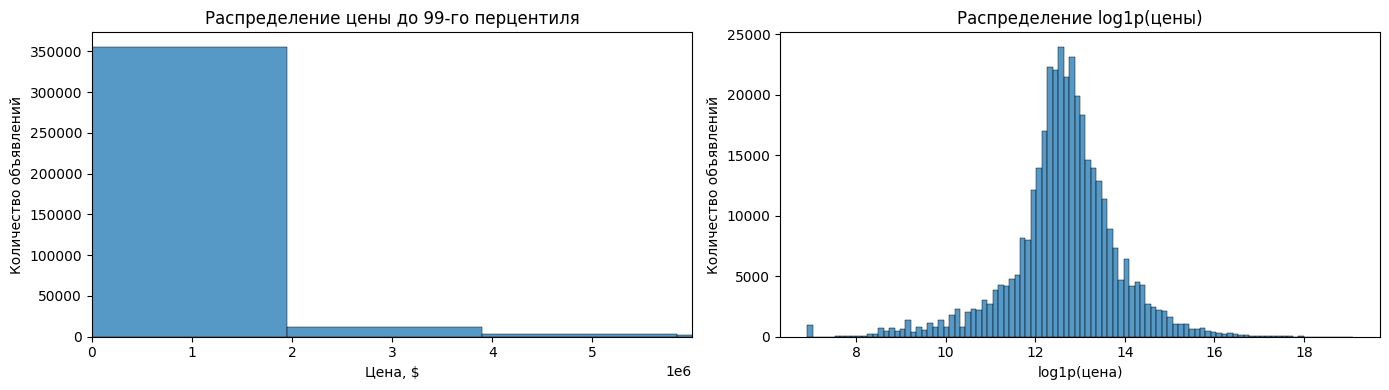

In [74]:
# Анализ распределения целевой переменной.

import matplotlib.pyplot as plt
import seaborn as sns

sales_df['log_price'] = np.log1p(sales_df['price'])

price_p99 = sales_df['price'].quantile(0.99)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 4))

sns.histplot(
    data=sales_df,
    x='price',
    bins=100,
    ax=axes[0]
)
axes[0].set_xlim(0, price_p99)
axes[0].set_title('Распределение цены до 99-го перцентиля')
axes[0].set_xlabel('Цена, $')
axes[0].set_ylabel('Количество объявлений')

sns.histplot(
    data=sales_df,
    x='log_price',
    bins=100,
    ax=axes[1]
)
axes[1].set_title('Распределение log1p(цены)')
axes[1].set_xlabel('log1p(цена)')
axes[1].set_ylabel('Количество объявлений')

plt.tight_layout()
plt.show()

Распределение цены имеет выраженный правый хвост: медиана составляет $320,000, тогда как среднее значение равно примерно $645,564. Крайне дорогие объекты существенно влияют на среднее и метрики в исходной денежной шкале.

Преобразование `log1p(price)` уменьшает асимметрию распределения и влияние редких дорогих объектов на обучение. Поэтому модель будет обучаться предсказывать `log_price`, а итоговые прогнозы и бизнес-метрики будут дополнительно переведены обратно в доллары с помощью `expm1`.

### Извлечение и очистка числовых признаков

Поля `sqft`, `beds`, `baths` и `stories` хранят числовую информацию в разных
текстовых форматах: с единицами измерения, дополнительными пояснениями,
разделителями тысяч и пропусками.

Для каждого поля используется отдельная функция преобразования. Это позволяет
извлекать значения с учётом смысла столбца: площадь определяется по маркеру
`sqft`, количество спален — по `bed` или `bd`, а количество ванных — по
`bath` или `ba`. Значения, не соответствующие физически допустимым диапазонам,
заменяются на пропуски и будут заполнены медианой только на обучающей выборке.

In [75]:
import re


def normalize_numeric_text(value) -> str:
    """Преобразует значение в нормализованную текстовую строку."""
    if pd.isna(value):
        return ''

    return (
        str(value)
        .strip()
        .lower()
        .replace(',', '')
    )


def parse_sqft(value) -> float:
    """Извлекает площадь объекта в квадратных футах."""
    text = normalize_numeric_text(value)

    if text in {'', '--', 'nan', 'none'}:
        return np.nan

    patterns = [
        r'(\d+(?:\.\d+)?)\s*(?:sq\.?\s*ft\.?|sqft)',
        r'(\d+(?:\.\d+)?)\s*$'
    ]

    for pattern in patterns:
        match = re.search(pattern, text)
        if match:
            return float(match.group(1))

    return np.nan


def parse_beds(value) -> float:
    """Извлекает количество спален."""
    text = normalize_numeric_text(value)

    if text in {'', '--', 'nan', 'none', 'studio'}:
        return np.nan

    patterns = [
        r'(\d+(?:\.\d+)?)\s*(?:beds?|bd)\b',
        r'^(\d+(?:\.\d+)?)$'
    ]

    for pattern in patterns:
        match = re.search(pattern, text)
        if match:
            return float(match.group(1))

    return np.nan


def parse_baths(value) -> float:
    """Извлекает количество ванных комнат."""
    text = normalize_numeric_text(value)

    if text in {'', '--', 'nan', 'none'}:
        return np.nan

    patterns = [
        r'(\d+(?:\.\d+)?)\s*(?:baths?|ba)\b',
        r'(?:bathrooms?\s*:?\s*)(\d+(?:\.\d+)?)',
        r'^(\d+(?:\.\d+)?)$'
    ]

    for pattern in patterns:
        match = re.search(pattern, text)
        if match:
            return float(match.group(1))

    return np.nan


def parse_stories(value) -> float:
    """Извлекает количество этажей."""
    text = normalize_numeric_text(value)

    if text in {'', '--', 'nan', 'none'}:
        return np.nan
    if text == 'studio':
        return 0.0

    patterns = [
        r'(\d+(?:\.\d+)?)\s*(?:stories|story|storeys|storey)\b',
        r'^(\d+(?:\.\d+)?)$'
    ]

    for pattern in patterns:
        match = re.search(pattern, text)
        if match:
            return float(match.group(1))

    return np.nan

In [76]:
# Извлечение числовых признаков из текстовых полей.

sales_df['sqft_num'] = sales_df['sqft'].apply(parse_sqft)
sales_df['beds_num'] = sales_df['beds'].apply(parse_beds)
sales_df['baths_num'] = sales_df['baths'].apply(parse_baths)
sales_df['stories_num'] = sales_df['stories'].apply(parse_stories)

numeric_columns = [
    'sqft_num',
    'beds_num',
    'baths_num',
    'stories_num'
]


def make_numeric_report(frame: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    """Формирует сводную таблицу числовых признаков."""
    return pd.DataFrame({
        'missing_pct': frame[columns].isna().mean().mul(100).round(2),
        'min': frame[columns].min(),
        'median': frame[columns].median(),
        'max': frame[columns].max()
    })


print('Сводка до обработки некорректных значений:')
display(make_numeric_report(sales_df, numeric_columns))

Сводка до обработки некорректных значений:


,missing_pct,min,median,max
sqft_num,10.92,0.0,1800.0,795979430.0
beds_num,29.67,0.0,3.0,144.0
baths_num,28.78,0.0,2.5,5000.0
stories_num,43.62,0.0,2.0,1120.0


In [77]:
# Контроль примеров извлечения значений.
# Он подтверждает, что парсеры корректно обрабатывают разные исходные форматы.

parse_check = sales_df[
    ['sqft', 'sqft_num', 'beds', 'beds_num', 'baths', 'baths_num', 'stories', 'stories_num']
].sample(
    n=min(15, len(sales_df)),
    random_state=RANDOM_STATE
)

display(parse_check)

,sqft,sqft_num,beds,beds_num,baths,baths_num,stories,stories_num
63455,629,629.0,1,1.0,1.0,1.0,NaN,NaN
42624,"2,926",2926.0,3,3.0,3.0,3.0,1.0,1.0
67147,"1,289",1289.0,NaN,NaN,NaN,NaN,NaN,NaN
251662,1716,1716.0,3,3.0,2,2.0,NaN,NaN
354373,"1,930",1930.0,Baths,NaN,Sq. Ft.,NaN,NaN,NaN
368370,"1,635 sqft",1635.0,NaN,NaN,NaN,NaN,1.0,1.0
265594,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
293289,1380,1380.0,2.0,2.0,2.5,2.5,Townhouse,NaN
254408,"Total interior livable area: 4,699 sqft",4699.0,5 bd,5.0,Bathrooms: 5,5.0,NaN,NaN
306623,"3,512",3512.0,4,4.0,4.0,4.0,2.0,2.0


In [78]:
# Физически допустимые интервалы признаков.
# Значения вне диапазонов считаются ошибками формата и заменяются на NaN.

valid_ranges = {
    'sqft_num': (100, 50_000),
    'beds_num': (0, 30),
    'baths_num': (0.5, 30),
    'stories_num': (1, 10)
}

invalid_counts = {}

for column, (lower_bound, upper_bound) in valid_ranges.items():
    invalid_mask = (
        sales_df[column].notna()
        & ~sales_df[column].between(lower_bound, upper_bound)
    )

    invalid_counts[column] = invalid_mask.sum()
    sales_df.loc[invalid_mask, column] = np.nan

invalid_report = (
    pd.Series(invalid_counts, name='invalid_values')
    .to_frame()
)

print('Количество значений, заменённых на NaN:')
display(invalid_report)

print('Сводка после обработки некорректных значений:')
display(make_numeric_report(sales_df, numeric_columns))

Количество значений, заменённых на NaN:


,invalid_values
sqft_num,13027
beds_num,91
baths_num,18464
stories_num,13273


Сводка после обработки некорректных значений:


,missing_pct,min,median,max
sqft_num,14.40,100.0,1838.0,50000.0
beds_num,29.69,0.0,3.0,30.0
baths_num,33.71,0.5,2.5,30.0
stories_num,47.16,1.0,2.0,10.0


In [79]:
# Проверка минимальных и максимальных допустимых значений после очистки.

inspection_columns = [
    'price',
    'propertyType',
    'city',
    'state',
    'sqft',
    'beds',
    'baths',
    'stories'
]

for column in numeric_columns:
    print(f'\nПроверка границ признака: {column}')

    print('Минимальные значения:')
    display(
        sales_df.loc[
            sales_df[column].notna(),
            [column] + inspection_columns
        ]
        .nsmallest(5, columns=column)
    )

    print('Максимальные значения:')
    display(
        sales_df.loc[
            sales_df[column].notna(),
            [column] + inspection_columns
        ]
        .nlargest(5, columns=column)
    )


Проверка границ признака: sqft_num
Минимальные значения:


,sqft_num,price,propertyType,city,state,sqft,beds,baths,stories
9261,100.0,789000.0,lot/land,Saint Johns,FL,100 sqft,NaN,NaN,NaN
62267,100.0,400000.0,Miscellaneous,Miami,FL,100 sqft,0,NaN,NaN
121653,100.0,700000.0,lot/land,Brooksville,FL,100 sqft,2 Beds,2 Baths,1.0
162864,100.0,20000.0,Single Family Home,Alexandria,VA,100,0,0,1
182169,100.0,401369.0,Single Family,Miami,FL,100 sqft,4,2.0,1.0


Максимальные значения:


,sqft_num,price,propertyType,city,state,sqft,beds,baths,stories
71505,50000.0,225000.0,coop,Brooklyn,NY,"50,000 sqft",NaN,2 Baths,NaN
244441,50000.0,990000.0,Multi-Family Home,Saint Albans Town,VT,50000,NaN,NaN,3
284189,49670.0,5000000.0,multi-family,Brownsville,TX,"49,670 sqft",NaN,NaN,NaN
109722,49660.0,385000.0,coop,Sunnyside,NY,"49,660 sqft",NaN,NaN,6.0
53097,49484.0,85000.0,lot/land,Panama City,FL,"49,484 sqft",NaN,NaN,NaN



Проверка границ признака: beds_num
Минимальные значения:


...

,baths_num,price,propertyType,city,state,sqft,beds,baths,stories
167137,30.0,3750000.0,townhouse,Fort Lauderdale,FL,NaN,34 Beds,30 Baths,2.0
231100,30.0,138000.0,Multi-Family Home,Marshall,MI,2100,4.0,30,2 Story
242978,30.0,3495000.0,multi-family,Van Nuys,CA,"11,180 sqft",26 Beds,30 Baths,2.0
246995,30.0,3750000.0,Townhouse,Dania Beach,FL,--,34,30.0,2
300841,30.0,289900.0,single-family home,Spring Hill,FL,"2,301 sqft",4 Beds,30 Baths,1.0



Проверка границ признака: stories_num
Минимальные значения:


,stories_num,price,propertyType,city,state,sqft,beds,baths,stories
2,1.0,2895000.0,single-family home,Los Angeles,CA,"3,000 sqft",3 Beds,2 Baths,1.0
12,1.0,525000.0,single-family home,Pembroke Pines,FL,"2,839 sqft",4 Beds,3 Baths,1.0
13,1.0,499900.0,Single Family,Eugene,OR,"Total interior livable area: 1,820 sqft",3 bd,Bathrooms: 2,1.0
19,1.0,626000.0,multi-family,Fort Lauderdale,FL,"1,612 sqft",4 Beds,4 Baths,1.0
21,1.0,3500000.0,Single Family,Bend,OR,"Total interior livable area: 5,266 sqft",5 bd,Bathrooms: 5,1.0


Максимальные значения:


,stories_num,price,propertyType,city,state,sqft,beds,baths,stories
13428,10.0,549000.0,Condo,Cincinnati,OH,"1,668",2,2.0,10
24931,10.0,400000.0,coop,Woodside,NY,675 sqft,NaN,NaN,10
30278,10.0,1068000.0,condo,Queens,NY,"1,045 sqft",2 Beds,2 Baths,10
30448,10.0,335000.0,coop,Bronx,NY,650 sqft,NaN,NaN,10
34689,10.0,750000.0,Cooperative,New York,NY,"49,000",1,2,10.0


### Вывод по числовым признакам

Текстовые поля площади, количества спален, ванных комнат и этажей преобразованы в числовые признаки с учётом их формата: единиц измерения, поясняющего текста и разделителей тысяч.

До обработки в датасете встречались нулевые и экстремально большие значения. Часть из них могла появиться из-за неоднозначного формата исходных полей, а часть — относиться к нетипичным крупным объектам. Значения за пределами выбранных рабочих диапазонов заменены на `NaN`; сами строки не удалялись.


### Тип недвижимости

Исходный признак `propertyType` содержит большое число вариантов написания:
синонимы, разные регистры, архитектурные стили и комбинированные типы
объектов. Для уменьшения количества редких категорий и повышения устойчивости
модели значения агрегируются в укрупнённые группы.

Земельные участки (`land`, `lot/land`) не являются жилыми объектами. Их
распределение цен отличается от распределения стоимости домов, поэтому они
исключаются из выборки в соответствии с целью проекта.

In [80]:
# Нормализация исходного признака propertyType.

property_type = (
    sales_df['propertyType']
    .fillna('missing')
    .astype(str)
    .str.strip()
    .str.lower()
)

print(f'Уникальных исходных значений propertyType: {property_type.nunique():,}')

display(
    property_type
    .value_counts()
    .head(30)
    .to_frame('listings')
)

Уникальных исходных значений propertyType: 1,272


,listings
propertyType,
single-family home,91150
single family,61884
condo,42358
missing,34538
single family home,31724
lot/land,20467
townhouse,18297
land,10928
multi-family,7762


In [81]:
def group_property_type(value: str) -> str:
    """Объединяет исходные типы недвижимости в устойчивые группы."""
    text = str(value).strip().lower()

    if text in {'', 'missing', 'nan', 'none'}:
        return 'missing'

    if re.search(r'\b(?:land|lot)\b', text):
        return 'land'

    if 'condo' in text or 'coop' in text or 'co-op' in text:
        return 'condo_coop'

    if 'town' in text or 'row home' in text:
        return 'townhouse'

    if any(token in text for token in ['multi', 'duplex', 'triplex', 'fourplex']):
        return 'multi_family'

    if 'mobile' in text or 'manufactured' in text:
        return 'mobile_manufactured'

    if 'apartment' in text:
        return 'apartment'

    if any(
        token in text
        for token in [
            'single',
            'detached',
            'ranch',
            'colonial',
            'traditional',
            'contemporary',
            'one story',
            'two story'
        ]
    ):
        return 'single_family'

    return 'other'


sales_df['property_group'] = property_type.apply(group_property_type)

property_summary = (
    sales_df
    .groupby('property_group', dropna=False)
    .agg(
        listings=('price', 'size'),
        median_price=('price', 'median'),
        mean_price=('price', 'mean')
    )
    .sort_values('listings', ascending=False)
)

property_summary['share_pct'] = (
    property_summary['listings']
    .div(len(sales_df))
    .mul(100)
    .round(2)
)

display(property_summary)

,listings,median_price,mean_price,share_pct
property_group,,,,
single_family,206427,334990.0,609663.130056,55.17
condo_coop,55142,369900.0,816657.679573,14.74
missing,34662,310000.0,860066.595407,9.26
land,31458,73000.0,316776.278784,8.41
townhouse,18480,319994.0,576174.586472,4.94
multi_family,12552,599000.0,952953.737014,3.35
other,11077,349000.0,636977.086937,2.96
mobile_manufactured,3560,99500.0,125224.073876,0.95
apartment,809,550000.0,962028.862794,0.22


In [82]:
# Земля исключается до обучения модели.
# Количество рассчитывается по property_group, а не по точному исходному тексту.

land_count = sales_df['property_group'].eq('land').sum()
land_share = land_count / len(sales_df) * 100

sales_df = sales_df.loc[
    sales_df['property_group'].ne('land')
].copy()

print(f'Исключено земельных участков: {land_count:,} ({land_share:.2f}%)')
print(f'Размер выборки после исключения земли: {sales_df.shape[0]:,} строк, {sales_df.shape[1]} столбцов')

Исключено земельных участков: 31,458 (8.41%)
Размер выборки после исключения земли: 342,709 строк, 25 столбцов


В текущем датасете в группу `land` вошли 31,458 объявлений (8.41% выборки), а их медианная цена составила $73,600. Это существенно отличается от медианных цен жилых категорий, поэтому такие объекты исключаются из модели оценки жилой недвижимости.

### Географические признаки

Стоимость недвижимости существенно различается между регионами. Поэтому в
модель будут включены `state`, `city` и `zipcode`. До обучения проверяются
пропуски, количество категорий и распределение объявлений по регионам.

In [83]:
geo_columns = ['state', 'city', 'zipcode']

geo_report = pd.DataFrame({
    'missing': sales_df[geo_columns].isna().sum(),
    'missing_pct': sales_df[geo_columns].isna().mean().mul(100).round(3),
    'unique': sales_df[geo_columns].nunique(dropna=True)
})

display(geo_report)

print('Топ-10 штатов по числу объявлений:')
display(
    sales_df['state']
    .value_counts()
    .head(10)
    .to_frame('listings')
)

print('Топ-10 городов по числу объявлений:')
display(
    sales_df['city']
    .value_counts()
    .head(10)
    .to_frame('listings')
)

,missing,missing_pct,unique
state,0,0.000,38
city,9,0.003,1908
zipcode,0,0.000,4469


Топ-10 штатов по числу объявлений:


,listings
state,
FL,101997
TX,77916
NY,23866
CA,22151
NC,18886
TN,15832
WA,12526
OH,11495
IL,8179


Топ-10 городов по числу объявлений:


,listings
city,
Houston,23278
Miami,15244
San Antonio,15018
Jacksonville,9467
Dallas,8399
Brooklyn,7183
New York,6902
Chicago,6327
Charlotte,6075


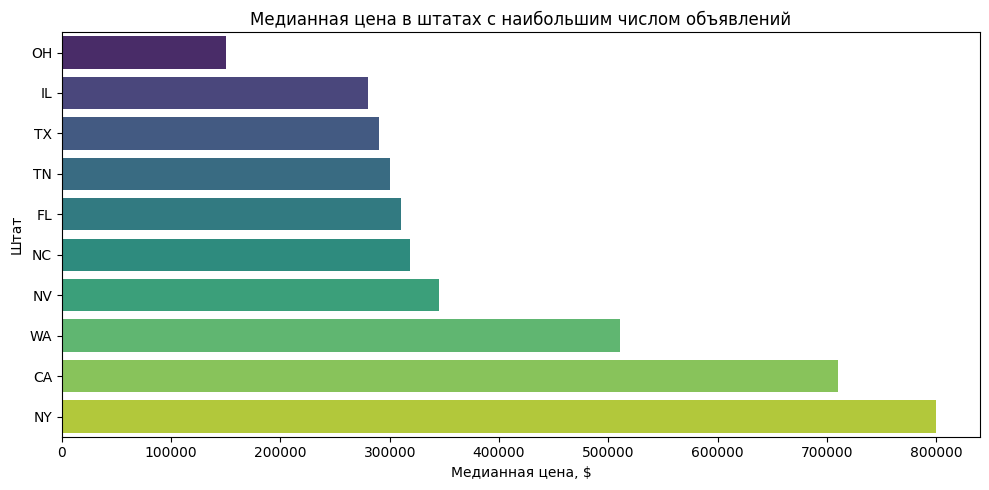

,state,listings,median_price
0,OH,11495,149900.0
1,IL,8179,279900.0
2,TX,77916,290000.0
3,TN,15832,299900.0
4,FL,101997,309900.0
5,NC,18886,319000.0
6,NV,7642,345000.0
7,WA,12526,510990.0
8,CA,22151,710000.0
9,NY,23866,800000.0


In [84]:
# Сравнение медианных цен в штатах с наибольшим числом объявлений.
# Используется медиана, потому что она устойчива к дорогим объектам в хвосте
# распределения цены.

top_states = sales_df['state'].value_counts().head(10).index

state_stats = (
    sales_df.loc[sales_df['state'].isin(top_states)]
    .groupby('state')
    .agg(
        listings=('price', 'size'),
        median_price=('price', 'median')
    )
    .sort_values('median_price')
    .reset_index()
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=state_stats,
    x='median_price',
    y='state',
    hue='state',
    legend=False,
    palette='viridis'
)

plt.title('Медианная цена в штатах с наибольшим числом объявлений')
plt.xlabel('Медианная цена, $')
plt.ylabel('Штат')
plt.tight_layout()
plt.show()

display(state_stats)

### Вывод по типу и географии

В десяти штатах с наибольшим количеством объявлений медианная цена различается более чем в пять раз: от $149,900 в Ohio до $800,000 в New York. Это подтверждает, что географические признаки содержат существенную информацию для прогнозирования стоимости объекта.

Признаки `state`, `city` и `zipcode` будут использоваться как категориальные, а не числовые: их значения идентифицируют территорию и не образуют линейную числовую шкалу.

### Бинарные признаки: бассейн и камин

Поля о бассейне и камине представлены в неоднородном текстовом виде и
содержат много пропусков. Из них формируются бинарные признаки наличия
бассейна и камина.

Из полей формируются бинарные индикаторы подтверждённого наличия бассейна и камина. Для бассейна используются два исходных столбца, объединённые в единый признак.
в объявлении может не совпадать с подтверждённым отсутствием камина.

In [85]:
# Бассейн.
# В двух исходных столбцах встречается признак наличия бассейна.
# Сначала используем PrivatePool, затем при пропуске — private pool.

pool_text = (
    sales_df['PrivatePool']
    .combine_first(sales_df['private pool'])
    .astype('string')
    .str.strip()
    .str.lower()
)

pool_yes_values = {'yes', 'true', '1'}

sales_df['has_pool'] = (
    pool_text
    .isin(pool_yes_values)
    .astype('int8')
)

# В данных бассейн в основном кодируется как "yes" или пропуск.
# has_pool интерпретируется как индикатор подтверждённого наличия бассейна.
# Непустые значения, отличные от yes/true/1, и пропуски получают значение 0.
# Отдельный индикатор пропуска для бассейна в модель не включается.

In [86]:
# Камин.
# Значения могут быть количествами, типами камина или текстовыми описаниями.

fireplace_text = (
    sales_df['fireplace']
    .astype('string')
    .str.strip()
    .str.lower()
)

no_fireplace_values = {
    '0',
    'no',
    'none',
    'nan',
    'not applicable',
    'false'
}

sales_df['fireplace_missing'] = fireplace_text.isna().astype('int8')

sales_df['has_fireplace'] = (
    fireplace_text.notna()
    & ~fireplace_text.isin(no_fireplace_values)
).astype('int8')

In [87]:
# Контроль распределения сформированных бинарных признаков.

binary_features = [
    'has_pool',
    'has_fireplace',
    'fireplace_missing'
]

binary_report = pd.DataFrame({
    'count_0': [(sales_df[col] == 0).sum() for col in binary_features],
    'count_1': [(sales_df[col] == 1).sum() for col in binary_features],
    'share_1_pct': [
        (sales_df[col].mean() * 100).round(2)
        for col in binary_features
    ]
}, index=binary_features)

display(binary_report)

,count_0,count_1,share_1_pct
has_pool,298863,43846,12.79
has_fireplace,243831,98878,28.85
fireplace_missing,101403,241306,70.41


## Извлечение года постройки

Из поля `homeFacts` извлекается год постройки объекта. Дополнительно создаётся индикатор `year_built_missing`, поскольку отсутствие этой характеристики в объявлении может содержать полезную информацию для модели.

Возраст объекта не рассчитывается: в датасете отсутствует дата публикации объявления, поэтому возраст на момент размещения нельзя определить без внешних предположений. В модель включаются `year_built` и `year_built_missing`.

In [90]:
# Извлечение года постройки из поля homeFacts.

import ast


def extract_fact(value, label: str):
    """Извлекает значение характеристики по её названию из homeFacts."""
    if pd.isna(value):
        return np.nan

    try:
        facts_data = ast.literal_eval(value)

        for fact in facts_data.get('atAGlanceFacts', []):
            fact_label = str(
                fact.get('factLabel', '')
            ).strip().lower()

            if fact_label == label.lower():
                fact_value = fact.get('factValue')

                if fact_value in {None, '', 'None'}:
                    return np.nan

                return fact_value

    except (ValueError, SyntaxError, TypeError, AttributeError):
        return np.nan

    return np.nan


sales_df['year_built'] = pd.to_numeric(
    sales_df['homeFacts'].apply(
        lambda value: extract_fact(value, 'Year built')
    ),
    errors='coerce'
)

# Год постройки — календарный признак. Невозможные или ошибочно
# распарсенные значения заменяются на NaN.

MIN_VALID_YEAR = 1600
MAX_VALID_YEAR = 2025

invalid_year_mask = (
    sales_df['year_built'].notna()
    & ~sales_df['year_built'].between(
        MIN_VALID_YEAR,
        MAX_VALID_YEAR
    )
)

invalid_year_count = invalid_year_mask.sum()

sales_df.loc[
    invalid_year_mask,
    'year_built'
] = np.nan

# Индикатор сохраняет информацию о пропуске года постройки.

sales_df['year_built_missing'] = (
    sales_df['year_built']
    .isna()
    .astype('int8')
)

print(f'Допустимый диапазон year_built: {MIN_VALID_YEAR}–{MAX_VALID_YEAR}')
print(f'Некорректных значений year_built: {invalid_year_count:,}')
print(f'Пропусков year_built: {sales_df["year_built"].isna().mean():.2%}')

display(
    sales_df[
        ['year_built', 'year_built_missing']
    ]
    .describe()
)

Допустимый диапазон year_built: 1600–2025
Некорректных значений year_built: 6
Пропусков year_built: 10.58%


,year_built,year_built_missing
count,306459.000000,342709.000000
mean,1979.658669,0.105775
std,33.466723,0.307550
min,1703.000000,0.000000
25%,1957.000000,0.000000
50%,1985.000000,0.000000
75%,2007.000000,0.000000
max,2025.000000,1.000000


Год постройки успешно извлечён для 306,459 объектов. В 10.58% объявлений эта характеристика отсутствует, поэтому в модель будут переданы как `year_built`, так и индикатор `year_built_missing`.

После проверки диапазона 6 некорректных значений были заменены на пропуски. Медианный год постройки составляет 1985, а диапазон корректных наблюдений — от 1703 до 2025 года.

### Статистический анализ числовых признаков

Для оценки связи числовых признаков с ценой используется коэффициент Спирмена.
Он подходит для монотонных зависимостей и менее чувствителен к выбросам, чем
линейная корреляция Пирсона.

Анализ проводится для `log_price`, поскольку исходная цена имеет выраженную
правостороннюю асимметрию.

,spearman_corr_with_log_price
baths_num,0.554477
sqft_num,0.554131
beds_num,0.318775
stories_num,0.279304
year_built,0.167661


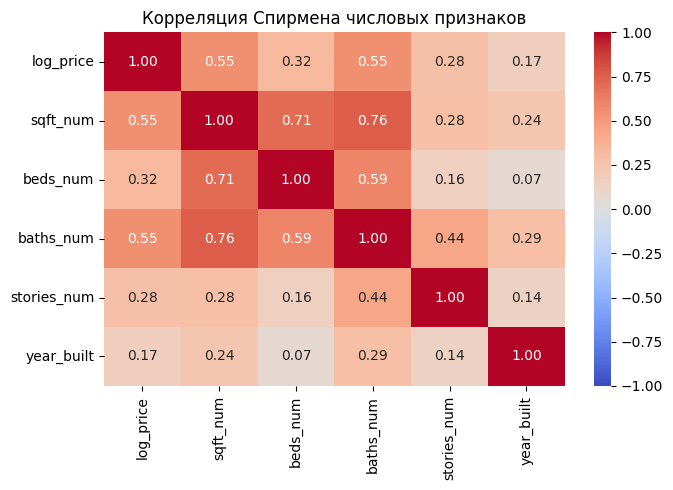

In [92]:
numeric_eda_features = [
    'log_price',
    'sqft_num',
    'beds_num',
    'baths_num',
    'stories_num',
    'year_built'
]

eda_numeric = sales_df[numeric_eda_features].copy()

spearman_matrix = eda_numeric.corr(method='spearman')

spearman_corr = (
    spearman_matrix['log_price']
    .drop('log_price')
    .sort_values(ascending=False)
)

display(
    spearman_corr
    .to_frame('spearman_corr_with_log_price')
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    spearman_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1
)

plt.title('Корреляция Спирмена числовых признаков')
plt.tight_layout()
plt.show()


Коэффициенты Спирмена показывают положительную монотонную связь всех рассмотренных числовых признаков с логарифмом цены.

Наиболее сильная связь наблюдается у числа ванных комнат (`baths_num`, \(\rho = 0.554\)) и площади (`sqft_num`, \(\rho = 0.554\)). Количество спален (`beds_num`, \(\rho = 0.319\)) и этажей (`stories_num`, \(\rho = 0.279\)) связано с ценой слабее. Год постройки имеет слабую положительную связь с ценой (`year_built`, \(\rho = 0.168\)): более новые объекты в среднем стоят дороже.


### Проверка различий цен по типам недвижимости
### Статистические гипотезы

Проверяется, различается ли распределение логарифма цены между группами типов недвижимости.

- \(H_0\): распределения `log_price`  одинаковы для всех групп `property_group`.
- \(H_1\): как минимум одна группа `property_group` имеет отличающееся распределение `log_price`.

Уровень значимости: \(\alpha = 0.05\).

Для проверки используется непараметрический критерий Kruskal–Wallis, поскольку сравниваются несколько независимых групп, а распределение исходной цены имеет выраженную асимметрию.

In [94]:
from scipy.stats import kruskal


property_groups = (
    sales_df
    .loc[
        sales_df['property_group'].ne('missing'),
        ['property_group', 'log_price']
    ]
    .dropna()
)

groups = [
    group_data['log_price'].to_numpy()
    for _, group_data in property_groups.groupby('property_group')
]

kruskal_stat, kruskal_p_value = kruskal(*groups)

group_summary = (
    property_groups
    .groupby('property_group')
    .agg(
        listings=('log_price', 'size'),
        median_log_price=('log_price', 'median')
    )
    .sort_values('listings', ascending=False)
)

print(f'Kruskal–Wallis H: {kruskal_stat:.2f}')
print(f'p-value: {kruskal_p_value:.3e}')

display(group_summary)

Kruskal–Wallis H: 8969.74
p-value: 0.000e+00


,listings,median_log_price
property_group,,
single_family,206427,12.721859
condo_coop,55142,12.820991
townhouse,18480,12.676061
multi_family,12552,13.303019
other,11077,12.762830
mobile_manufactured,3560,11.507923
apartment,809,13.217675


Тест Kruskal–Wallis выявил статистически значимые различия распределений `log_price` между группами недвижимости: \(H = 8969.74\), \(p < 0.001\). Нулевая гипотеза об одинаковом распределении логарифма цены для всех групп отвергается.

Различия имеют практическую интерпретацию: минимальный медианный `log_price` наблюдается у `mobile_manufactured` (\(11.508\)), а более высокие значения — у `multi_family` (\(13.303\)) и `apartment` (\(13.218\)). Поэтому `property_group` включается в итоговый набор признаков модели как категориальный признак.

## Итоговый набор признаков

В итоговый набор включаются числовые характеристики объекта: площадь, количество спален, ванных комнат, этажей и год постройки. Также используются признаки наличия бассейна и камина, индикаторы пропусков, укрупнённая группа типа недвижимости и географические признаки.

In [95]:
feature_cols = [
    'sqft_num',
    'beds_num',
    'baths_num',
    'stories_num',
    'year_built',
    'year_built_missing',
    'has_pool',
    'has_fireplace',
    'fireplace_missing',
    'property_group',
    'state',
    'city',
    'zipcode'
]

feature_report = pd.DataFrame({
    'dtype': sales_df[feature_cols].dtypes.astype(str),
    'missing': sales_df[feature_cols].isna().sum(),
    'missing_pct': sales_df[feature_cols].isna().mean().mul(100).round(2),
    'unique': sales_df[feature_cols].nunique(dropna=True)
})

display(feature_report)

,dtype,missing,missing_pct,unique
sqft_num,float64,26348,7.69,8841
beds_num,float64,82170,23.98,31
baths_num,float64,95279,27.80,60
stories_num,float64,146965,42.88,18
year_built,float64,36250,10.58,219
year_built_missing,int8,0,0.00,2
has_pool,int8,0,0.00,2
has_fireplace,int8,0,0.00,2
fireplace_missing,int8,0,0.00,2
property_group,object,0,0.00,8


### Разделение данных на train, validation и test

Обучающая выборка используется для обучения моделей. Валидационная выборка
используется для сравнения baseline, Ridge и CatBoost, а также для подбора
гиперпараметров CatBoost. Test-выборка не используется на этом этапе и
оставляется для единственной финальной проверки выбранной модели.

In [96]:
from sklearn.model_selection import train_test_split

X = sales_df[feature_cols].copy()
y = sales_df['log_price'].copy()

X_train_valid, X_test, y_train_valid, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_valid,
    y_train_valid,
    test_size=0.15,
    random_state=RANDOM_STATE
)

# Проверка отсутствия пересечений между выборками.

train_index = set(X_train.index)
valid_index = set(X_valid.index)
test_index = set(X_test.index)

assert train_index.isdisjoint(valid_index), (
    'Обнаружено пересечение индексов train и validation.'
)
assert train_index.isdisjoint(test_index), (
    'Обнаружено пересечение индексов train и test.'
)
assert valid_index.isdisjoint(test_index), (
    'Обнаружено пересечение индексов validation и test.'
)
assert len(train_index | valid_index | test_index) == len(X), (
    'Не все объекты попали ровно в одну выборку.'
)

print('Проверка пройдена: пересечений между train, validation и test нет.')

print(f'\nTrain:      {X_train.shape[0]:,} объектов ({len(X_train) / len(X):.1%})')
print(f'Validation: {X_valid.shape[0]:,} объектов ({len(X_valid) / len(X):.1%})')
print(f'Test:       {X_test.shape[0]:,} объектов ({len(X_test) / len(X):.1%})')

print('\nРазмерности матриц признаков:')
print(f'X_train: {X_train.shape}')
print(f'X_valid: {X_valid.shape}')
print(f'X_test:  {X_test.shape}')

Проверка пройдена: пересечений между train, validation и test нет.

Train:      233,041 объектов (68.0%)
Validation: 41,126 объектов (12.0%)
Test:       68,542 объектов (20.0%)

Размерности матриц признаков:
X_train: (233041, 13)
X_valid: (41126, 13)
X_test:  (68542, 13)


### Baseline и линейная модель Ridge

Для оценки полезности ML-моделей строится baseline: всем объектам validation-выборки
присваивается медианное значение целевой переменной из train-выборки.

Затем baseline сравнивается с Ridge-регрессией. Для Ridge числовые признаки
заполняются медианой и масштабируются, а категориальные признаки кодируются
методом One-Hot Encoding. Все преобразования выполняются внутри Pipeline,
обучаемого только на train-выборке.

In [97]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    median_absolute_error,
    r2_score,
    root_mean_squared_error
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


def calculate_regression_metrics(y_log_true, y_log_pred) -> dict:
    """
    Рассчитывает метрики регрессии в исходной и логарифмической шкалах.

    Parameters
    ----------
    y_log_true : array-like
        Фактические значения log1p(price).
    y_log_pred : array-like
        Предсказания модели для log1p(price).

    Returns
    -------
    dict
        Набор метрик качества модели.
    """
    y_price_true = np.expm1(y_log_true)
    y_price_pred = np.expm1(y_log_pred)

    return {
        'MAE_$': mean_absolute_error(y_price_true, y_price_pred),
        'Median_AE_$': median_absolute_error(y_price_true, y_price_pred),
        'RMSE_$': root_mean_squared_error(y_price_true, y_price_pred),
        'R2_$': r2_score(y_price_true, y_price_pred),
        'log_RMSE': root_mean_squared_error(y_log_true, y_log_pred),
        'log_R2': r2_score(y_log_true, y_log_pred)
    }


def print_regression_metrics(
    metrics: dict,
    title: str
) -> None:
    """Выводит метрики регрессии в читаемом формате."""
    currency_metrics = {'MAE_$', 'Median_AE_$', 'RMSE_$'}

    print(title)

    for metric_name, metric_value in metrics.items():
        if metric_name in currency_metrics:
            print(f'{metric_name}: ${metric_value:,.0f}')
        else:
            print(f'{metric_name}: {metric_value:.3f}')


# Baseline: всем объектам validation присваивается медиана log_price,
# рассчитанная только на train-выборке.

baseline_log_pred_valid = np.full(
    shape=len(y_valid),
    fill_value=y_train.median()
)

baseline_metrics_valid = calculate_regression_metrics(
    y_log_true=y_valid,
    y_log_pred=baseline_log_pred_valid
)

print_regression_metrics(
    baseline_metrics_valid,
    'Baseline на validation-выборке:'
)


# Разделение итоговых признаков по типам.

numeric_features = [
    'sqft_num',
    'beds_num',
    'baths_num',
    'stories_num',
    'year_built',
    'year_built_missing',
    'has_pool',
    'has_fireplace',
    'fireplace_missing'
]

categorical_features = [
    'property_group',
    'state',
    'city',
    'zipcode'
]

# Все преобразования обучаются исключительно на X_train внутри Pipeline.

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    (
        'onehot',
        OneHotEncoder(
            handle_unknown='ignore',
            min_frequency=20
        )
    )
])

ridge_preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', numeric_transformer, numeric_features),
        ('categorical', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

ridge_model = Pipeline(steps=[
    ('preprocessor', ridge_preprocessor),
    ('model', Ridge(alpha=10.0))
])

# Обучение Ridge на train и оценка на validation.

ridge_model.fit(X_train, y_train)

ridge_log_pred_valid = ridge_model.predict(X_valid)

ridge_metrics_valid = calculate_regression_metrics(
    y_log_true=y_valid,
    y_log_pred=ridge_log_pred_valid
)

print_regression_metrics(
    ridge_metrics_valid,
    'Ridge на validation-выборке:'
)


# Сравнение моделей на одной validation-выборке.

validation_models_report = pd.DataFrame(
    [
        {'model': 'Median baseline', **baseline_metrics_valid},
        {'model': 'Ridge (log_price)', **ridge_metrics_valid}
    ]
).set_index('model')

display(validation_models_report.round(3))

Baseline на validation-выборке:
MAE_$: $464,483
Median_AE_$: $160,099
RMSE_$: $1,786,350
R2_$: -0.034
log_RMSE: 1.045
log_R2: -0.001
Ridge на validation-выборке:
MAE_$: $361,340
Median_AE_$: $71,931
RMSE_$: $8,910,837
R2_$: -24.728
log_RMSE: 0.551
log_R2: 0.721


,MAE_$,Median_AE_$,RMSE_$,R2_$,log_RMSE,log_R2
model,,,,,,
Median baseline,464483.376,160099.000,1786350.219,-0.034,1.045,-0.001
Ridge (log_price),361339.891,71931.291,8910836.654,-24.728,0.551,0.721


Модель Ridge существенно превосходит медианный baseline на validation-выборке. Значение `log_RMSE` снизилось с 1.045 до 0.551, а коэффициент детерминации для `log_price` вырос с около 0 до 0.721. Медианная абсолютная ошибка в денежной шкале снизилась с $160,099 до $71,931.

Основной метрикой выбора модели будет `log_RMSE`, поскольку обучение выполняется на `log_price`, а распределение исходной цены имеет длинный правый хвост. Метрика `Median_AE_$` используется как бизнес-интерпретируемая оценка типичной ошибки в долларах.

Отрицательное значение \(R^2\) в исходной денежной шкале для Ridge связано с отдельными крупными ошибками на дорогих объектах после обратного преобразования `expm1`. Поэтому сравнение моделей будет выполняться прежде всего по качеству в логарифмической шкале и медианной абсолютной ошибке.

## CatBoost на validation-выборке

CatBoost сравнивается с baseline и Ridge на той же validation-выборке. Модель обучается только на train-выборке, а validation используется для выбора числа итераций через early stopping и оценки качества.

Категориальные признаки передаются в CatBoost как строковые значения. Числовые пропуски сохраняются в виде `NaN`: CatBoost обрабатывает их в процессе обучения.

In [99]:
from catboost import CatBoostRegressor


cat_features = [
    'property_group',
    'state',
    'city',
    'zipcode'
]


def prepare_catboost_features(
    frame: pd.DataFrame,
    categorical_columns: list[str]
) -> pd.DataFrame:
    """Подготавливает категориальные признаки для CatBoost."""
    prepared_frame = frame.copy()

    for column in categorical_columns:
        prepared_frame[column] = (
            prepared_frame[column]
            .fillna('missing')
            .astype(str)
        )

    return prepared_frame


X_train_cb = prepare_catboost_features(
    X_train,
    cat_features
)

X_valid_cb = prepare_catboost_features(
    X_valid,
    cat_features
)

cat_feature_indices = [
    X_train_cb.columns.get_loc(column)
    for column in cat_features
]

catboost_valid = CatBoostRegressor(
    loss_function='RMSE',
    eval_metric='RMSE',
    iterations=3_000,
    depth=8,
    learning_rate=0.05,
    random_seed=RANDOM_STATE,
    verbose=200,
    allow_writing_files=False
)

catboost_valid.fit(
    X_train_cb,
    y_train,
    cat_features=cat_feature_indices,
    eval_set=(X_valid_cb, y_valid),
    early_stopping_rounds=200,
    use_best_model=True
)

catboost_log_pred_valid = catboost_valid.predict(X_valid_cb)

catboost_metrics_valid = calculate_regression_metrics(
    y_log_true=y_valid,
    y_log_pred=catboost_log_pred_valid
)

print_regression_metrics(
    catboost_metrics_valid,
    'CatBoost на validation-выборке:'
)

best_iterations = catboost_valid.get_best_iteration() + 1

print(f'\nОптимальное число итераций: {best_iterations:,}')

validation_models_report = pd.DataFrame(
    [
        {'model': 'Median baseline', **baseline_metrics_valid},
        {'model': 'Ridge (log_price)', **ridge_metrics_valid},
        {'model': 'CatBoost (log_price)', **catboost_metrics_valid}
    ]
).set_index('model')

display(
    validation_models_report
    .sort_values('log_RMSE')
    .round(3)
)

0:	learn: 1.0314007	test: 1.0156882	best: 1.0156882 (0)	total: 766ms	remaining: 38m 17s
200:	learn: 0.4858554	test: 0.4735645	best: 0.4735645 (200)	total: 1m 1s	remaining: 14m 17s
400:	learn: 0.4584763	test: 0.4489054	best: 0.4489054 (400)	total: 1m 58s	remaining: 12m 45s
600:	learn: 0.4438456	test: 0.4372675	best: 0.4372675 (600)	total: 2m 55s	remaining: 11m 40s
800:	learn: 0.4338531	test: 0.4303926	best: 0.4303926 (800)	total: 3m 51s	remaining: 10m 35s
1000:	learn: 0.4263656	test: 0.4258203	best: 0.4258203 (1000)	total: 4m 49s	remaining: 9m 37s
1200:	learn: 0.4202612	test: 0.4222454	best: 0.4222454 (1200)	total: 5m 47s	remaining: 8m 40s
1400:	learn: 0.4154535	test: 0.4195357	best: 0.4195357 (1400)	total: 6m 46s	remaining: 7m 43s
1600:	learn: 0.4111037	test: 0.4173681	best: 0.4173666 (1599)	total: 7m 41s	remaining: 6m 43s
1800:	learn: 0.4074129	test: 0.4158640	best: 0.4158599 (1799)	total: 8m 37s	remaining: 5m 44s
2000:	learn: 0.4038469	test: 0.4143199	best: 0.4143199 (2000)	total: 9m

,MAE_$,Median_AE_$,RMSE_$,R2_$,log_RMSE,log_R2
model,,,,,,
CatBoost (log_price),196067.098,47522.525,1043833.481,0.647,0.409,0.847
Ridge (log_price),361339.891,71931.291,8910836.654,-24.728,0.551,0.721
Median baseline,464483.376,160099.000,1786350.219,-0.034,1.045,-0.001


CatBoost показал лучшее качество на validation-выборке и выбран финальной моделью. Он достиг `log_RMSE = 0.409` и \(R^2 = 0.847\) для `log_price`, тогда как Ridge показал `log_RMSE = 0.551` и \(R^2 = 0.721\).

В денежной шкале медианная абсолютная ошибка CatBoost составила $47,523, что ниже результата Ridge ($71,931) и медианного baseline ($160,099). MAE CatBoost равна $196,067.

В проверенном диапазоне до 3,000 итераций validation-ошибка продолжала уменьшаться; лучшее значение достигнуто на последней итерации. Поэтому для финального обучения используется конфигурация CatBoost с 3,000 итераций, глубиной 8 и `learning_rate = 0.05`.

## Финальная модель CatBoost

По результатам сравнения на validation-выборке для финального решения выбрана модель CatBoostRegressor. После выбора архитектуры и гиперпараметров модель переобучается на объединённых train- и validation-выборках.

Отложенная test-выборка не участвует в обучении и используется один раз только для итоговой оценки качества модели.

In [102]:
# Объединяем train и validation после выбора финальной модели.

X_train_final = pd.concat([X_train, X_valid], axis=0)
y_train_final = pd.concat([y_train, y_valid], axis=0)

print(f'Размер train + validation: {X_train_final.shape}')
print(f'Размер test: {X_test.shape}')

X_train_final_cb = prepare_catboost_features(
    X_train_final,
    cat_features
)

X_test_cb = prepare_catboost_features(
    X_test,
    cat_features
)

cat_feature_indices = [
    X_train_final_cb.columns.get_loc(column)
    for column in cat_features
]

FINAL_ITERATIONS = best_iterations

final_catboost = CatBoostRegressor(
    loss_function='RMSE',
    iterations=FINAL_ITERATIONS,
    depth=8,
    learning_rate=0.05,
    random_seed=RANDOM_STATE,
    verbose=200,
    allow_writing_files=False
)

final_catboost.fit(
    X_train_final_cb,
    y_train_final,
    cat_features=cat_feature_indices
)

# Единственное предсказание на отложенной test-выборке.

final_log_pred = final_catboost.predict(X_test_cb)

assert len(final_log_pred) == len(y_test), (
    'Количество прогнозов не совпадает с размером test-выборки.'
)

final_metrics_test = calculate_regression_metrics(
    y_log_true=y_test,
    y_log_pred=final_log_pred
)

print_regression_metrics(
    final_metrics_test,
    'Финальное качество CatBoost на test-выборке:'
)

final_test_report = (
    pd.DataFrame(
        [final_metrics_test],
        index=['CatBoost (final)']
    )
    .round(3)
)

display(final_test_report)

Размер train + validation: (274167, 13)
Размер test: (68542, 13)
0:	learn: 1.0277065	total: 423ms	remaining: 21m 8s
200:	learn: 0.4831401	total: 1m 11s	remaining: 16m 40s
400:	learn: 0.4561057	total: 2m 30s	remaining: 16m 17s
600:	learn: 0.4428408	total: 3m 47s	remaining: 15m 7s
800:	learn: 0.4329019	total: 4m 56s	remaining: 13m 34s
1000:	learn: 0.4256209	total: 6m 5s	remaining: 12m 9s
1200:	learn: 0.4197398	total: 7m 24s	remaining: 11m 6s
1400:	learn: 0.4147660	total: 8m 24s	remaining: 9m 35s
1600:	learn: 0.4106625	total: 9m 29s	remaining: 8m 17s
1800:	learn: 0.4067127	total: 10m 31s	remaining: 7m
2000:	learn: 0.4031854	total: 11m 38s	remaining: 5m 48s
2200:	learn: 0.4001970	total: 12m 42s	remaining: 4m 36s
2400:	learn: 0.3974335	total: 13m 45s	remaining: 3m 25s
2600:	learn: 0.3944171	total: 14m 46s	remaining: 2m 16s
2800:	learn: 0.3916644	total: 15m 48s	remaining: 1m 7s
2999:	learn: 0.3890959	total: 16m 48s	remaining: 0us
Финальное качество CatBoost на test-выборке:
MAE_$: $203,254
M

,MAE_$,Median_AE_$,RMSE_$,R2_$,log_RMSE,log_R2
CatBoost (final),203253.949,47901.001,1126458.252,0.638,0.416,0.846


## Анализ ошибок финальной модели на test-выборке

Итоговая проверка качества проводится на отложенной test-выборке. Для интерпретации ошибок сравним фактическую цену с прогнозом, а также оценим качество в ценовых сегментах.

Абсолютные ошибки в долларах особенно чувствительны к редким дорогим объектам, поэтому наряду с MAE рассмотрим медианную абсолютную ошибку и ошибку в логарифмической шкале.

In [105]:
# Преобразование фактических значений и прогнозов из log1p(price) в цену.

y_test_price = np.expm1(y_test)
final_price_pred = np.expm1(final_log_pred)

assert len(y_test_price) == len(final_price_pred), (
    'Количество фактических цен и прогнозов не совпадает.'
)

# Таблица результатов финальной модели.

test_results = X_test.copy()

test_results['actual_log_price'] = y_test.to_numpy()
test_results['predicted_log_price'] = final_log_pred

test_results['actual_price'] = y_test_price.to_numpy()
test_results['predicted_price'] = final_price_pred

# Положительная ошибка означает переоценку стоимости моделью,
# отрицательная — недооценку.

test_results['error'] = (
    test_results['predicted_price']
    - test_results['actual_price']
)

test_results['absolute_error'] = test_results['error'].abs()

test_results['absolute_percentage_error'] = (
    test_results['absolute_error']
    .div(test_results['actual_price'])
)

# Квинтили строятся по фактической цене объектов test-выборки.

test_results['price_segment'] = pd.qcut(
    test_results['actual_price'],
    q=5,
    duplicates='drop'
)

error_by_segment = (
    test_results
    .groupby('price_segment', observed=True)
    .agg(
        listings=('actual_price', 'size'),
        median_actual_price=('actual_price', 'median'),
        mae=('absolute_error', 'mean'),
        median_ae=('absolute_error', 'median'),
        mdape_pct=(
            'absolute_percentage_error',
            lambda values: values.median() * 100
        ),
        mean_error=('error', 'mean'),
        median_error=('error', 'median')
    )
)

display(error_by_segment.round(2))
display(test_results[
    [
        'actual_price',
        'predicted_price',
        'error',
        'absolute_error',
        'absolute_percentage_error',
        'price_segment'
    ]
].head())

,listings,median_actual_price,mae,median_ae,mdape_pct,mean_error,median_error
price_segment,,,,,,,
"(999.999, 180000.0]",13805,119900.0,36702.62,23539.19,24.02,20192.63,11798.80
"(180000.0, 279900.0]",13630,230297.5,40109.30,26627.69,11.59,8970.20,2954.20
"(279900.0, 410000.0]",13788,339900.0,59616.40,40541.12,12.03,9947.58,744.88
"(410000.0, 709000.0]",13621,525000.0,114510.46,76904.45,14.60,17563.74,-1547.31
"(709000.0, 115000000.0]",13698,1219399.0,766266.96,276532.59,21.92,-430431.17,-126376.89


,actual_price,predicted_price,error,absolute_error,absolute_percentage_error,price_segment
11833,159900.0,112833.908697,-47066.091303,47066.091303,0.294347,"(999.999, 180000.0]"
177047,540000.0,430603.235841,-109396.764159,109396.764159,0.202587,"(410000.0, 709000.0]"
107064,55000.0,87814.303045,32814.303045,32814.303045,0.596624,"(999.999, 180000.0]"
332234,487500.0,840234.413591,352734.413591,352734.413591,0.723558,"(410000.0, 709000.0]"
13180,515000.0,468904.012396,-46095.987604,46095.987604,0.089507,"(410000.0, 709000.0]"


In [106]:
# Ошибка в разрезе типа недвижимости.

error_by_property_group = (
    test_results
    .groupby('property_group', observed=True)
    .agg(
        listings=('actual_price', 'size'),
        median_actual_price=('actual_price', 'median'),
        median_ae=('absolute_error', 'median'),
        mdape_pct=(
            'absolute_percentage_error',
            lambda values: values.median() * 100
        ),
        mean_error=('error', 'mean'),
        median_error=('error', 'median')
    )
    .sort_values('listings', ascending=False)
)

display(error_by_property_group.round(2))

,listings,median_actual_price,median_ae,mdape_pct,mean_error,median_error
property_group,,,,,,
single_family,41287,334990.0,43734.47,14.02,-47630.43,264.67
condo_coop,11040,375000.0,55443.25,16.28,-63066.90,2455.46
missing,6929,310000.0,69226.01,30.43,-253558.44,4382.27
townhouse,3663,325000.0,39167.98,12.93,-53377.96,-1393.47
multi_family,2503,618988.0,109777.75,22.74,-125626.53,-560.06
other,2230,345000.0,52118.30,16.31,-71187.36,5562.80
mobile_manufactured,740,99975.0,24067.36,26.48,-11678.26,-1387.44
apartment,150,549500.0,108864.47,22.03,-143940.51,9339.66


In [107]:
# Качество в штатах с достаточным количеством объектов.

error_by_state = (
    test_results
    .groupby('state', observed=True)
    .agg(
        listings=('actual_price', 'size'),
        median_actual_price=('actual_price', 'median'),
        median_ae=('absolute_error', 'median'),
        mdape_pct=(
            'absolute_percentage_error',
            lambda values: values.median() * 100
        ),
        mean_error=('error', 'mean'),
        median_error=('error', 'median')
    )
    .query('listings >= 100')
    .sort_values('listings', ascending=False)
)

display(error_by_state.round(2))

,listings,median_actual_price,median_ae,mdape_pct,mean_error,median_error
state,,,,,,
FL,20325,310000.0,44484.53,15.60,-59015.48,2016.27
TX,15501,289000.0,34910.73,12.51,-31961.92,1660.38
NY,4776,799250.0,166489.11,24.04,-399947.79,-7637.14
CA,4448,716593.0,117894.33,17.82,-133073.05,16583.42
NC,3840,324900.0,43280.15,14.36,-34735.71,24.62
TN,3116,299900.0,40188.40,15.40,-49283.27,-764.26
WA,2504,514900.0,70699.32,14.68,-56796.26,5480.92
OH,2305,149000.0,31088.13,22.56,-21769.19,-3095.59
IL,1662,275000.0,50272.48,19.63,-37060.53,-9649.57


### Ошибки по типу недвижимости

Наиболее устойчивые результаты модель показывает для массовых типов жилья. Для `single_family` медианная относительная ошибка составляет 14.02%, а для `townhouse` — 12.93%. Ошибки выше для более неоднородных или редких сегментов: `multi_family` имеет MdAPE 22.74%, `mobile_manufactured` — 26.48%.

Наименее точные прогнозы получены для записей с отсутствующим типом объекта (`property_group = missing`): MdAPE достигает 30.43%. Следовательно, полнота признака типа недвижимости существенно влияет на качество оценки и может использоваться как индикатор пониженной надёжности прогноза.

### Ошибки по штатам

Качество модели различается между штатами. Среди крупнейших рынков наиболее низкая медианная относительная ошибка наблюдается в Техасе — 12.51%; во Флориде она составляет 15.60%. Для Нью-Йорка характерна более высокая ошибка: MdAPE равна 24.04%, а медианная абсолютная ошибка — $166,489. Это связано с более высокой стоимостью и неоднородностью объектов рынка.

Средняя ошибка отрицательна в большинстве штатов, однако её не следует интерпретировать отдельно от медианной ошибки: редкие дорогие объекты существенно влияют на среднее значение. Поэтому для оценки типичной точности в разрезах использовались медианная абсолютная и медианная относительная ошибки.

## Итоговые выводы и ограничения

Для прогнозирования стоимости недвижимости выбрана CatBoostRegressor, обученная на объединённых train- и validation-данных. На независимой test-выборке модель достигла `log_RMSE = 0.416` и \(R^2 = 0.846\) в логарифмической шкале целевой переменной. В исходной шкале цены MAE составила $203,254, а медианная абсолютная ошибка — $47,901.

Модель наиболее полезна для массовых объектов среднего ценового диапазона. Наиболее высокая относительная точность наблюдается для объектов стоимостью примерно от $180,000 до $410,000. Качество заметно снижается для дешёвых объявлений, редких типов недвижимости, записей с пропущенным `property_group` и верхнего ценового сегмента.

Главное ограничение связано с редкими дорогими объектами: модель в среднем занижает цены в верхнем ценовом квинтиле. Дополнительно точность ограничена составом исходных признаков: в модели отсутствуют характеристики состояния объекта, даты публикации, площадь участка, число парковочных мест, школьные рейтинги, локальная инфраструктура и рыночная динамика.

Для практического использования прогноз следует сопровождать интервалом неопределённости или предупреждением о пониженной надёжности, особенно для дорогих объектов и записей с неполными характеристиками. Улучшить модель можно за счёт расширения признаков, отдельного моделирования дорогого сегмента и анализа выбросов.

## Визуальный анализ качества финальной модели

График сравнивает фактическую и предсказанную стоимость на отложенной test-выборке. Пунктирная диагональ соответствует идеальному прогнозу.

Для читаемости оси ограничиваются 99-м перцентилем фактических и предсказанных цен, рассчитанным по всей test-выборке. Это позволяет показать качество в массовом сегменте без доминирования редких премиальных объектов.

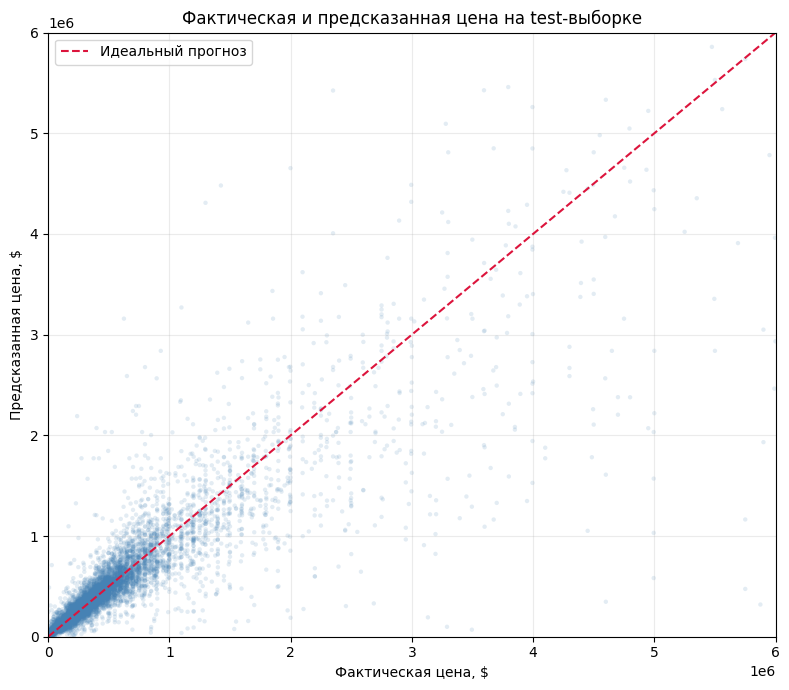

In [109]:
# Визуальная проверка соответствия фактических и прогнозных цен.

plot_df = test_results.sample(
    n=min(10_000, len(test_results)),
    random_state=RANDOM_STATE
)

plot_limit = (
    plot_df[['actual_price', 'predicted_price']]
    .quantile(0.99)
    .max()
)

plt.figure(figsize=(8, 7))

plt.scatter(
    plot_df['actual_price'],
    plot_df['predicted_price'],
    alpha=0.15,
    s=10,
    color='steelblue',
    edgecolors='none'
)

plt.plot(
    [0, plot_limit],
    [0, plot_limit],
    color='crimson',
    linestyle='--',
    linewidth=1.5,
    label='Идеальный прогноз'
)

plt.xlim(0, plot_limit)
plt.ylim(0, plot_limit)
plt.xlabel('Фактическая цена, $')
plt.ylabel('Предсказанная цена, $')
plt.title('Фактическая и предсказанная цена на test-выборке')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

На диаграмме наблюдается выраженная положительная связь между фактической и предсказанной стоимостью: основная часть точек располагается вдоль линии идеального прогноза. Это визуально подтверждает способность модели различать более дешёвые и более дорогие объекты.

Разброс точек увеличивается с ростом цены. Для дорогих объектов чаще встречаются точки ниже диагонали, что соответствует выявленной тенденции CatBoost занижать стоимость верхнего ценового сегмента. Ограничение осей 99-м перцентилем позволяет оценить качество на основной массе рынка без доминирования редких экстремально дорогих объектов.

### Сохранение модели

Финальная модель и метаданные сохраняются отдельно. Метаданные фиксируют
порядок входных признаков, перечень категориальных полей и преобразование
целевой переменной. Это позволяет использовать модель для предсказаний на
новых объявлениях без повторного обучения.

In [ ]:
import joblib

MODEL_PATH = 'catboost_real_estate.cbm'
METADATA_PATH = 'real_estate_model_metadata.joblib'

final_catboost.save_model(MODEL_PATH)

artifact = {
    'feature_columns': X_train_final.columns.tolist(),
    'categorical_features': cat_features,
    'target_transform': 'log1p',
    'model_type': 'CatBoostRegressor',
    'random_state': RANDOM_STATE,
    'iterations': FINAL_ITERATIONS,
    'model_params': final_catboost.get_params()
}

joblib.dump(artifact, METADATA_PATH)

print(f'Модель сохранена: {MODEL_PATH}')
print(f'Метаданные сохранены: {METADATA_PATH}')

Модель сохранена: catboost_real_estate.cbm
Метаданные сохранены: real_estate_model_metadata.joblib


In [111]:
from pathlib import Path
import joblib

ARTIFACTS_DIR = Path('artifacts')
ARTIFACTS_DIR.mkdir(exist_ok=True)

MODEL_PATH = ARTIFACTS_DIR / 'catboost_real_estate.cbm'
METADATA_PATH = ARTIFACTS_DIR / 'real_estate_model_metadata.joblib'

final_catboost.save_model(str(MODEL_PATH))

artifact = {
    'feature_columns': X_train_final.columns.tolist(),
    'categorical_features': cat_features,
    'target_transform': 'log1p',
    'model_type': 'CatBoostRegressor',
    'random_state': RANDOM_STATE,
    'iterations': FINAL_ITERATIONS,
    'model_params': final_catboost.get_params()
}

joblib.dump(artifact, METADATA_PATH)

print(f'Модель сохранена: {MODEL_PATH.resolve()}')
print(f'Метаданные сохранены: {METADATA_PATH.resolve()}')

assert MODEL_PATH.exists(), 'Файл модели не был создан.'
assert METADATA_PATH.exists(), 'Файл метаданных не был создан.'

Модель сохранена: C:\Users\aleks\Documents\IDE\Итоговый проект первого года обучения\artifacts\catboost_real_estate.cbm
Метаданные сохранены: C:\Users\aleks\Documents\IDE\Итоговый проект первого года обучения\artifacts\real_estate_model_metadata.joblib


In [112]:
import joblib
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor


def load_real_estate_model(
    model_path=MODEL_PATH,
    metadata_path=METADATA_PATH
):
    """Загружает модель CatBoost и её метаданные."""
    if not model_path.exists():
        raise FileNotFoundError(
            f'Не найден файл модели: {model_path.resolve()}'
        )

    if not metadata_path.exists():
        raise FileNotFoundError(
            f'Не найден файл метаданных: {metadata_path.resolve()}'
        )

    loaded_model = CatBoostRegressor()
    loaded_model.load_model(str(model_path))

    loaded_metadata = joblib.load(metadata_path)

    return loaded_model, loaded_metadata


model, metadata = load_real_estate_model()

feature_columns = metadata['feature_columns']
categorical_features = metadata['categorical_features']

print('Модель и метаданные успешно загружены.')
print(f'Количество признаков: {len(feature_columns)}')

Модель и метаданные успешно загружены.
Количество признаков: 13


In [113]:
example_listing = X_test.iloc[0].to_dict()

predicted_price = predict_price(example_listing)
actual_price = float(np.expm1(y_test.iloc[0]))

print(f'Фактическая цена: ${actual_price:,.0f}')
print(f'Прогноз модели: ${predicted_price:,.0f}')
print(f'Абсолютная ошибка: ${abs(actual_price - predicted_price):,.0f}')

Фактическая цена: $159,900
Прогноз модели: $112,834
Абсолютная ошибка: $47,066


## Итоговый вывод

В проекте разработана модель `CatBoostRegressor` для первичной оценки стоимости жилой недвижимости по характеристикам объекта, типу жилья и географическим признакам.

Целевая переменная преобразована с помощью `log1p(price)`. Это уменьшило влияние редких дорогих объектов на обучение и позволило модели лучше описывать относительные различия цен. Конфигурация CatBoost была выбрана по результатам validation-выборки. После выбора гиперпараметров модель была переобучена на объединённых train- и validation-данных, а отложенная test-выборка использовалась один раз для финальной независимой оценки.

На test-выборке из 68,542 объявлений финальная модель достигла следующих значений:

- MAE: $203,254
- Медианная абсолютная ошибка: $47,901
- RMSE: $1,126,458
- \(R^2\) в исходной шкале цены: 0.638
- log RMSE: 0.416
- \(R^2\) для `log_price`: 0.846

Модель наиболее применима для быстрой первичной оценки объектов массового сегмента. Наиболее устойчивые результаты получены для объектов стоимостью примерно от $180,000 до $410,000, а также для типов `single_family` и `townhouse`.

Ограничение модели связано с дорогими и уникальными объектами: в верхнем ценовом квинтиле ошибка возрастает, а прогнозы имеют тенденцию к недооценке. Поэтому для премиальной недвижимости, редких типов жилья и объявлений с неполными данными прогноз следует использовать вместе с экспертной оценкой, а не как единственный источник решения.

Финальная модель сохранена в файле `catboost_real_estate.cbm`; метаданные, необходимые для подготовки новых объектов и воспроизводимого инференса, сохранены в `real_estate_model_metadata.joblib`.